# 3. Four cameras: does learning `R` per camera rescue it?

Notebook 1 learned `R` for one camera and the belief got worse. The obvious reply is that four cameras are not one camera: they differ, they hand over, and each could carry its own noise level. Does per-camera learning behave any better?

---

**What this notebook implements**

The same variational loop, with every camera's observations offered. Each camera accumulates
its own $\Psi_c$ and $\nu_c$ from its own detections, while all four remain coupled through
the shared smoothed trajectory. The amount of usable data per camera appears in the width
of its posterior.

**What came out**

No. On the diagnostic run `notebook_5hz` with current plain floor IPM, the ungated
in-sample plug-in log-fit over the same 349 camera measurements prefers learned `R` by
**293 nats**. But filter-belief median NEES against Gazebo `gt_x/gt_y`, over 998 grid/update
steps, is **43.7** versus **9.21** for `R_total` commissioned on the three named earlier
captures (the calibrated 2-D reference is 1.386). Fit and belief calibration therefore
order the arms oppositely on this run. Every camera's learned noise is below the
commissioned value. Camera B offers only 36 observations (26 enter the gated covariance
update), so its posterior stays wide. Status: diagnostic mechanism evidence.

**What to do about it**

> **Per-camera learning is not the fix.** The failure is not about how many cameras share one number; it is that the error has a mean and the model has no term for one. Four cameras do buy something — but it is identifiability, not a better `R`, and that is notebook 4.

---

Here “learning `R`” is exactly the 12-pass coordinate-ascent routine introduced in
notebook 1, `nm.learn_R`. It is run once on the complete sequence, not once per camera
and not separately at every time step. There are four posterior factors
$q(\mathbf R_A),\ldots,q(\mathbf R_D)$, but they remain coupled through the one smoothed
trajectory $q(\mathbf x_{0:T})$.

**Evidence scope.** These are filter-belief and model-fit diagnostics on
`notebook_5hz`, under the current plain floor-IPM projection. The method sees odometry,
camera IDs and projected measurements online. `gt_x/gt_y` is evaluation-only. Do not use
this route-confounded demonstration to rank A–D measurement accuracy; the current balanced
camera comparison is `PG-IPM-CURRENT`, outside this notebook.

In [1]:
import notebook_data as nd
import notebook_model as nm
import notebook_views as nv
import numpy as np

nv.style()
commissioned = nm.commissioned_noise()

## 1. The run, and all four cameras

Coverage is a relay with holes in it: 35% of steps carry an observation, and which camera
is talking changes several times along the aisle.

In [2]:
capture = nd.load_capture()
truth_table = nd.load_truth(capture.name)
models = nd.camera_models()
window = nd.route_window(capture.name)
seq = nm.Sequence(capture, truth_table, window=window)
n_obs = int(seq.observed.sum())

nv.report_sequence(seq, n_obs, window, capture, truth_table)

driven route: simulated seconds 111.8 to 211.5 (100 s)
grid:          998 steps at 10 Hz (100 s)
observed:      349 steps (35%)
unobserved:    649 steps (65%) -- these are pure prediction
truth present: 998 steps

  A:   88 of the observed steps
  B:   36 of the observed steps
  C:  160 of the observed steps
  D:   65 of the observed steps


### Which camera is talking, and when

This is the coverage relay in one picture. The southern pair sees the robot first,
the northern pair takes over, and in between there is a stretch where the robot is
tracked by dead reckoning alone.

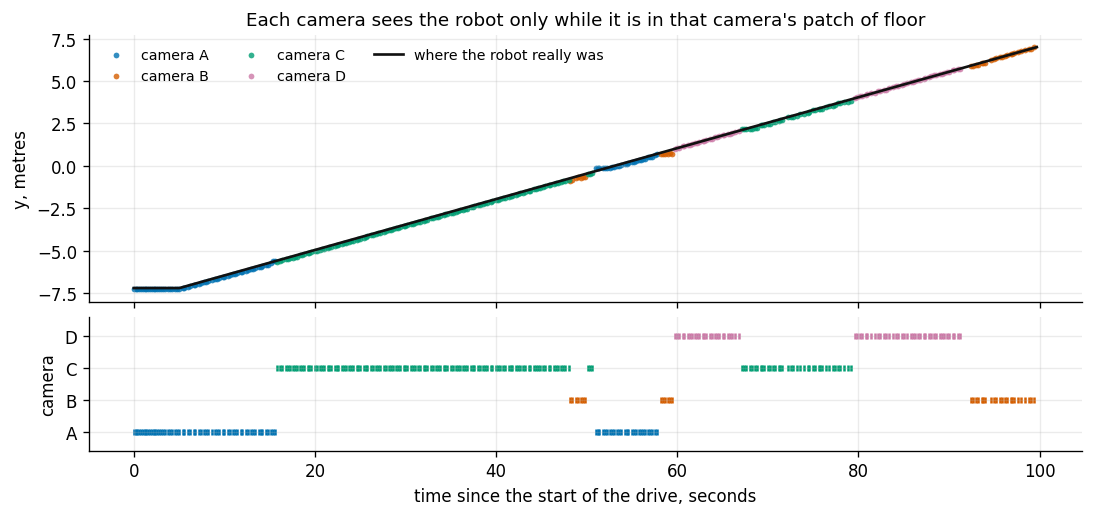

In [3]:
nv.camera_relay(seq)

### Why the four are not interchangeable

Before learning anything, look at what each camera contributed. The detector is the same
weights on all four, so a gap in detection rate is not a detector difference — it is
shelving between the camera and the robot. This is what sets how much each camera's
posterior can narrow later.

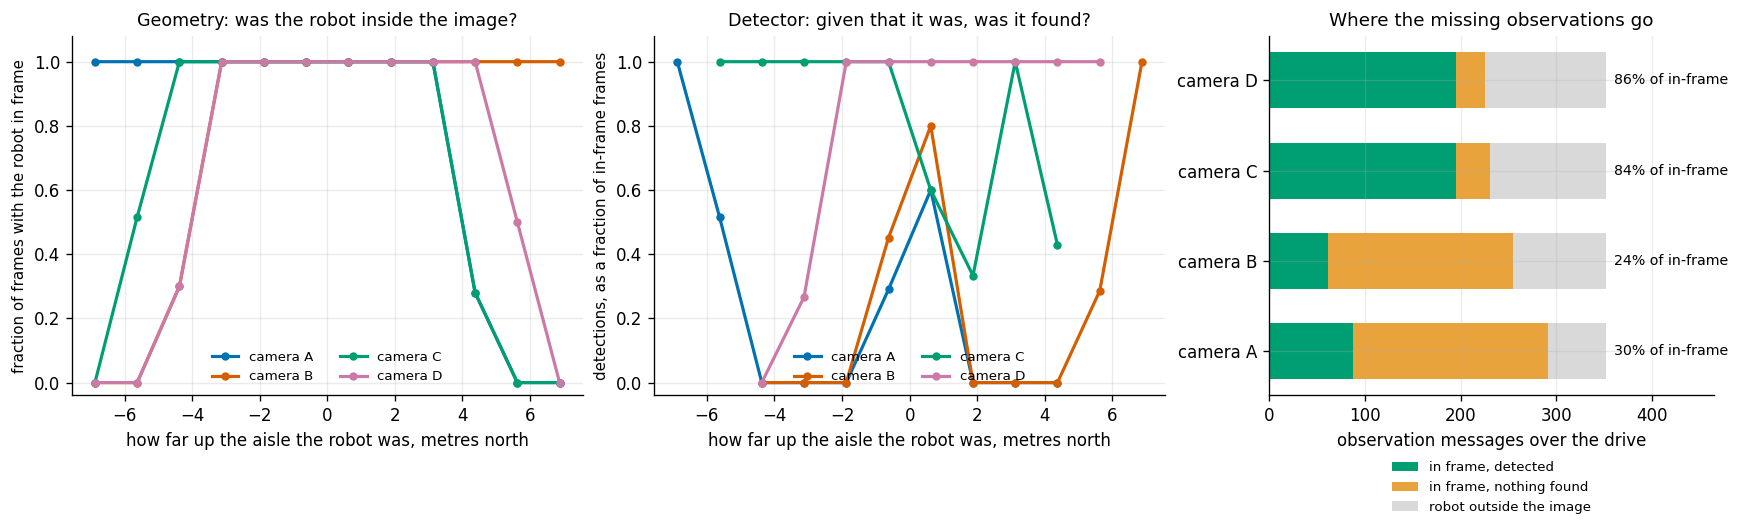

  camera   messages  in frame  detected  of in-frame    range detected
  A             352       291        88         0.30     5.3 to 11.6 m
  B             352       255        61         0.24     5.4 to 11.6 m
  C             352       231       195         0.84     8.7 to 15.8 m
  D             352       226       195         0.86     8.7 to 14.9 m

  3 detections arrived while the robot was outside the image ({'A': 0, 'B': 0, 'C': 0, 'D': 3}).
  Those are the detector boxing something that is not the robot -- the gate's job.


In [4]:
messages = nd.load_messages(capture.name)
outcomes = nm.message_outcomes(messages, truth_table, models, window=window)
north = nm.northing_of(outcomes, truth_table)

nv.detector_outcomes(outcomes, north)

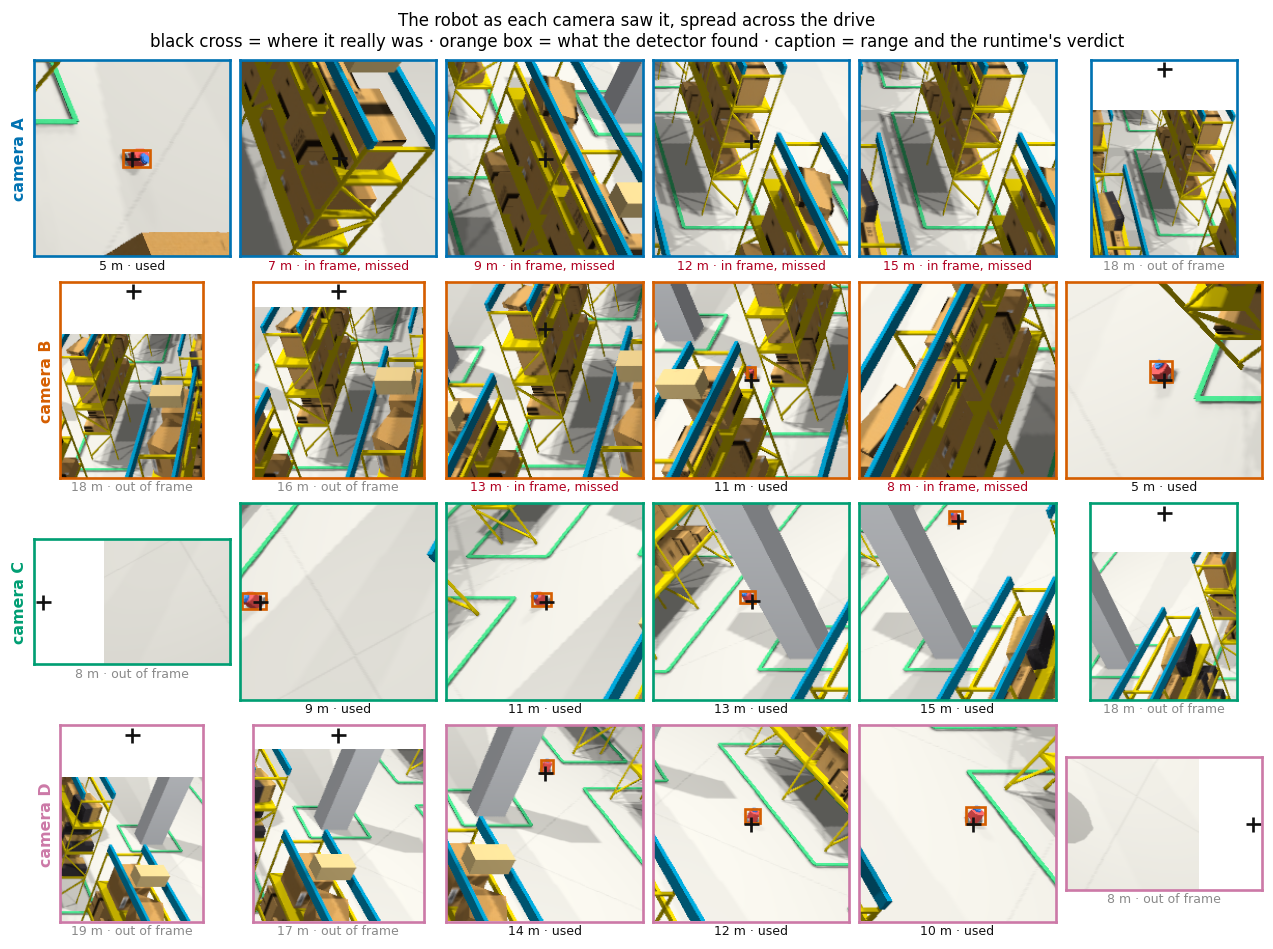

In [5]:
nv.detector_gallery(capture, models, truth_table, messages, window)

## 2. The same loop, four cameras

Identical to notebook 1 except that the covariance update partitions residuals by camera.
In outer pass $j$, `nm.learn_R` performs

$$q_j(\mathbf x_{0:T})\leftarrow
\texttt{RTS}\!\left(\texttt{KalmanFilter}(\{\bar{\mathbf R}_{c,j-1}\})\right),$$

then, for each camera $c$,

$$\Psi_{c,j}=\Psi_0+\sum_{k\in\mathcal K_c}
\left[(\mathbf y_k-\mathbf m^s_{k,j})(\mathbf y_k-\mathbf m^s_{k,j})^\top
+\mathbf P^s_{k,j}\right],\quad
\nu_{c,j}=\nu_0+n_c,\quad
\bar{\mathbf R}_{c,j}=\frac{\Psi_{c,j}}{\nu_{c,j}}.$$

`iterations=12` repeats those two blocks twelve times. The ordinary Kalman loop inside
each pass still iterates chronologically over 998 time steps. These are two different
notions of “iteration.” Each camera uses its own residual rows, but all four affect the
smoothed path and therefore affect one another indirectly.

In [6]:
forward = nm.kalman_filter(seq, commissioned["R_total"])
smooth = nm.rts_smoother(seq, forward)
time = seq.stamps - seq.stamps[0]
R_learned, history, vb = nm.learn_R(seq)

nv.report_learning(history)

    pass    how well it fits   learned noise, cm
       0              1607.4   A= 2.44  B= 4.34  C= 2.15  D= 2.58
       1              1652.8   A= 1.80  B= 3.56  C= 1.55  D= 2.29
       2              1642.5   A= 1.63  B= 3.11  C= 1.44  D= 2.29
       3              1637.3   A= 1.60  B= 2.97  C= 1.41  D= 2.29
      12              1633.5   A= 1.60  B= 2.88  C= 1.37  D= 2.29
  (passes 4 to 11 omitted; nothing moves after 3)


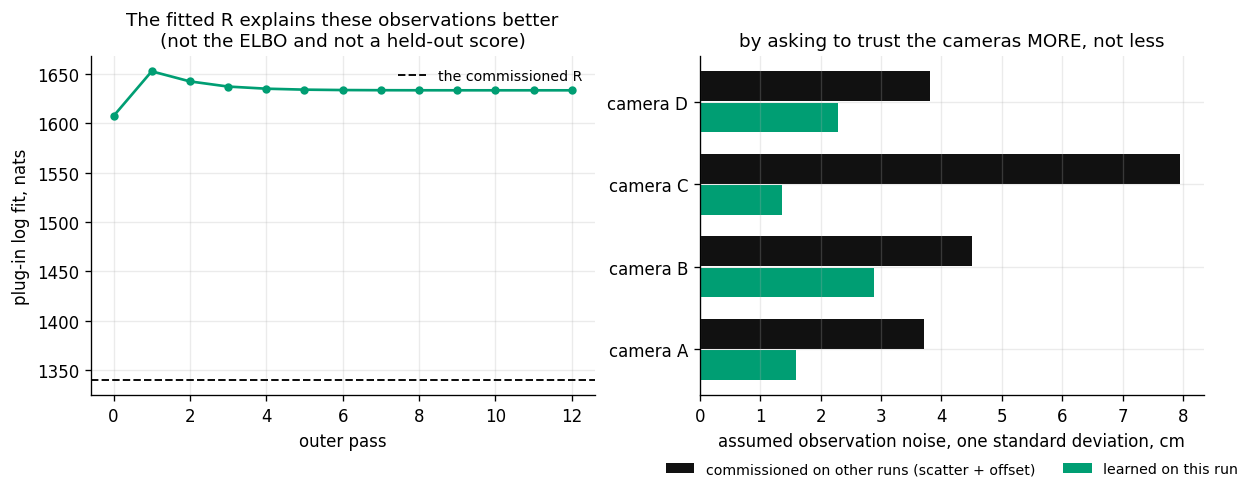

  camera A: commissioned  3.72 cm  ->  learned  1.60 cm   (  76 observations)
  camera B: commissioned  4.50 cm  ->  learned  2.88 cm   (  26 observations)
  camera C: commissioned  7.95 cm  ->  learned  1.37 cm   ( 155 observations)
  camera D: commissioned  3.81 cm  ->  learned  2.29 cm   (  32 observations)


In [7]:
forward_learned = nm.kalman_filter(seq, R_learned)
smooth_learned = nm.rts_smoother(seq, forward_learned)

nv.learned_R_summary(seq, history, R_learned, commissioned["sigma_total_m"], commissioned)

### What the posterior over `R` actually looks like

The output of each covariance update is a distribution, not only a point matrix. For one
axis of a two-dimensional inverse-Wishart the marginal on a variance is inverse-gamma, so
the density over standard deviation follows by the change of variables
$p(\sigma)=p(\sigma^2)2\sigma$. Cameras with hundreds of usable observations get a narrow
posterior; camera B offered 36 observations but only 26 entered this gated update, so its
posterior remains wider and the prior remains visible.

The right-hand panel is the same story in one number per camera: how far the posterior
has moved from the prior, in nats. It is the term that appears in the ELBO with a minus
sign — the price paid for departing from the prior, which the fit has to earn back.

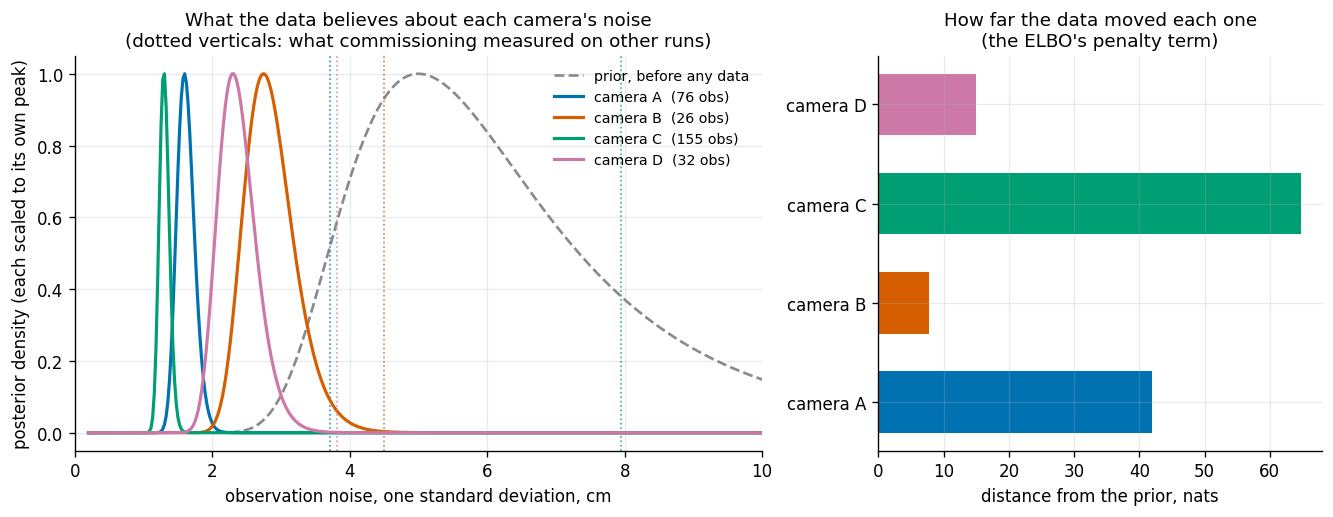

the east axis of each camera's noise, as a posterior rather than a number:
  camera      obs  posterior mean        68% interval   from the prior
                               cm                  cm             nats
  A            76            1.63        1.49 to 1.75             42.0
  B            26            2.89        2.50 to 3.22              7.8
  C           155            1.31        1.23 to 1.38             64.8
  D            32            2.40        2.10 to 2.66             14.9

More observations means a narrower posterior and a larger distance from the prior:
camera C has the most of both, camera B the fewest.


In [8]:
nv.posterior_over_R(vb, history, commissioned["sigma_total_m"])

### Better fit, worse belief

The reported observation-fit number goes up, while belief calibration gets worse. Be
precise about that first number: it is the **ungated plug-in log marginal likelihood**
$\log p(\mathbf y\mid\bar{\mathbf R})$ computed by a Kalman filter at a fixed covariance.
It is not the variational objective (the ELBO), and because $\bar{\mathbf R}$ was fitted
on this sequence it is not held-out model-selection evidence. It answers only “how well
does this fixed covariance explain these recorded observations?” What a robot also needs
is an honest belief: when it says “I am here, give or take 5 cm,” the give-or-take should
be calibrated.

One computational note before the numbers, because it changes them. The gate admits a
different subset of observations for every $\mathbf{R}$, so the running log evidence of
section 3 sums over *different data* for each arm and cannot be used to compare them.
Everything below recomputes it with the gate off, over all 349 observations. Doing it
the sloppy way overstated the gap between learned and commissioned by about a hundred
nats.

The measure of honesty is the normalised squared error,

$$\text{NEES}_k = \left(\mathbf{x}^{\text{true}}_k - \mathbf{m}_k\right)^{\!\top}
  \mathbf{P}_k^{-1}\left(\mathbf{x}^{\text{true}}_k - \mathbf{m}_k\right)$$

which for an honest two-dimensional belief has median $1.386$. Above that, the
filter is claiming more precision than it has.

Watch the smoothed rows in the table below, because they are counter-intuitive.
Smoothing gets *closer* to the truth and *further* from honest at the same time. It
narrows $\mathbf{P}$, which is the whole point of using later observations — but the
part of the error that comes from a per-camera offset does not shrink, because every
observation carries the same offset and averaging them cannot remove it. A smaller
covariance around an error that stays put is exactly what overconfidence is.

The companion is a strictly proper score, the negative log predictive density

$$\text{NLPD} = -\log \mathcal{N}\!\left(\mathbf{x}^{\text{true}}; \mathbf{m}, \mathbf{P}\right)
  = \tfrac{1}{2}\left(\text{NEES} + \log\det 2\pi\mathbf{P}\right)$$

which cannot be improved by lying in either direction: claiming too little
precision is punished by the volume term, claiming too much by the error term.
Distance from truth alone — RMSE — would not settle this, because it does not look
at $\mathbf{P}$ at all.

In [9]:
forward_spread = nm.kalman_filter(seq, commissioned["R_spread"])
forward_all = nm.kalman_filter(seq, commissioned["R_total"], gate=float("inf"))
scores = [
    nm.honesty(forward_spread, seq, "commissioned scatter only, filtered"),
    nm.honesty(forward, seq, "commissioned scatter + offset, filtered"),
    nm.honesty(forward_learned, seq, "learned R, filtered"),
    nm.honesty(smooth, seq, "commissioned scatter + offset, smoothed"),
    nm.honesty(smooth_learned, seq, "learned R, smoothed"),
]

nv.report_fit_versus_honesty(scores, seq, forward, forward_all, forward_learned, history,
                             commissioned=commissioned)

                                          median NEES  score (lower better)   distance
                                        (1.39 = honest)                         RMSE, cm
  commissioned scatter only, filtered           25.86                  7.80        8.4
  commissioned scatter + offset, filtered         9.21                  1.16        8.4
  learned R, filtered                           43.68                 20.68        7.7
  commissioned scatter + offset, smoothed        14.46                  4.89        7.0
  learned R, smoothed                           83.81                 41.81        7.1

plug-in log fit, all 349 observations, gate off, so the rows use the same data:


  arm                                log fit, nats   median NEES
  commissioned scatter only                 1504.4         25.86
  commissioned scatter + offset             1340.1          9.21
  learned on this run                       1633.5         43.68

  best fit first:      learned on this run  >  commissioned scatter only  >  commissioned scatter + offset
  most honest first:   commissioned scatter + offset  >  commissioned scatter only  >  learned on this run
  the two orderings are exact opposites: True


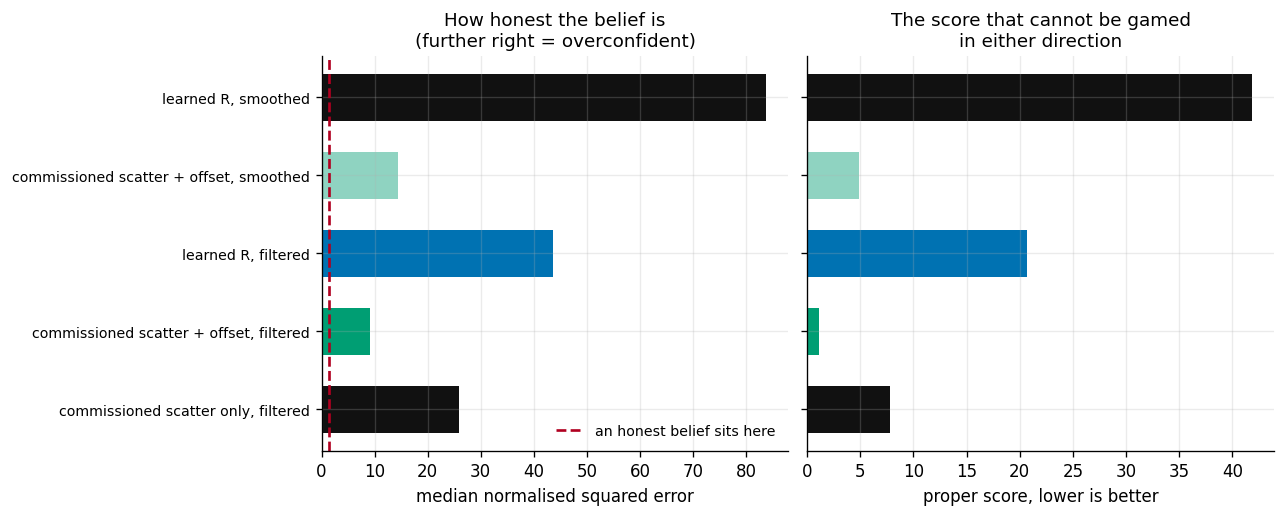

In [10]:
nv.fit_versus_honesty(scores)

### Watching it fit, one half-step at a time

The outer loop is two moves repeated, and the animation below shows them **separately** — one
frame per half-step — because the whole story is in the alternation.

* **Trajectory step:** refit $q(\mathbf x_{0:T})$ using the current
  $\bar{\mathbf{R}}$. Watch the
  middle panel: the path moves towards the observations.
* **Covariance step:** refit each $q(\mathbf R_c)$ to its expected residual scatter. Watch the
  ellipses in the left panel collapse.

The thing to notice is *where the clouds already are on pass 0*. They are tight — a couple of
centimetres — before any learning has happened at all. That is not because the observations
are good; it is because the smoother has already bent the path onto them. Two thirds of the
steps have no observation and the process noise is permissive, so the path has the freedom to
go where the observations point, and it takes it.

So the covariance step opens with a cloud that looks excellent and duly concludes the
cameras are precise. The next trajectory step, now trusting them more, pulls the path even
further onto them. Round and round: **each half-step is locally correct, and the pair of them
walks the filter into overconfidence.** The right panel is the price.

Nothing here is a re-enactment; each frame is an actual iterate.

In [11]:
nv.animate_the_fitting(seq, forward, time)

16 half-steps (8 passes)


   pass       assumed noise, cm (A/B/C/D)  median NEES
      0               5.00 5.00 5.00 5.00        14.91
      1               2.44 4.34 2.15 2.58        30.50
      2               1.80 3.56 1.55 2.29        39.34
      3               1.63 3.11 1.44 2.29        42.10
      4               1.60 2.97 1.41 2.29        43.07
      5               1.60 2.91 1.38 2.29        43.56
      6               1.60 2.89 1.37 2.29        43.68
      7               1.60 2.88 1.37 2.29        43.68


### Why learning it makes things worse

This is the result worth taking away, and it is not the one that was expected.

Learning $\mathbf{R}$ does not ask for more noise to cover the offset. It asks for
**less** — every camera's learned standard deviation comes out below what
commissioning measured. And the belief gets correspondingly less honest.

The mechanism is in the trajectory step. Two thirds of the steps have no observation, and the
process noise is permissive, so the smoothed trajectory has real freedom to bend. Given
observations that are all displaced the same way, the cheapest explanation available to
the smoother is not "the camera is biased" — it has no term for that — but "the robot
was over there". So it bends the path towards the displaced observations. The covariance step
then measures the residuals *about that bent path*, finds them small, and duly returns
a small $\hat{\mathbf{R}}$. The next trajectory step trusts the cameras even more. The offset has
been laundered into the state estimate.

That is why the distance from truth improves slightly (the path is being pulled towards
observations that are wrong in a consistent direction, which happens to reduce squared
error here) while the honesty collapses: the filter ends up *confidently* wrong instead
of *cautiously* wrong. It is the failure mode that matters most for a robot, and the
plug-in observation-fit score rose by nearly three hundred nats while it happened.

Note also what the well-commissioned baseline achieved. Simply inflating
$\mathbf{R}$ to include the offset — paying for the bias out of the only pocket the
model has — took the median normalised error from 25.9 to 9.2 and the proper score from
7.8 to 1.2, with no change to the estimate itself. That is the best a zero-mean model
can do, and it is still six times too confident.

And notice what the plug-in fit score made of that arm: it ranked it **last** of the three. The
printout above puts the three arms in order by fit and in order by honesty, and the two
orderings are exact reverses on this run. Choosing only by in-sample observation fit here
would therefore pick the least calibrated belief of the three; that is the demonstrated
warning, without claiming how a different dataset would behave.

The last cell makes the point directly: subtract each camera's measured average
offset before filtering, and see what happens to the honesty of the belief. This
uses ground truth to compute the offsets, so it is a diagnostic and not a
deployable method — it establishes what the ceiling would be if the offsets could be
estimated without truth, which is the subject of the offset-state work elsewhere in
this repository.

In [12]:
residuals = {cam: np.asarray([seq.y[i] - seq.truth[i] for i, c in enumerate(seq.camera)
                              if c == cam and np.isfinite(seq.truth[i, 0])])
             for cam in nd.CAMERAS}
offsets = {cam: res.mean(axis=0) for cam, res in residuals.items() if len(res)}
seq_corrected = nm.OffsetCorrected(seq, offsets)
R_corrected, _, _ = nm.learn_R(seq_corrected)
final = scores + [
    nm.honesty(nm.kalman_filter(seq_corrected, commissioned["R_spread"]), seq_corrected,
               "offsets removed, scatter-only R"),
    nm.honesty(nm.kalman_filter(seq_corrected, R_corrected), seq_corrected,
               "offsets removed, learned R"),
]

nv.report_offsets_removed(final, R_learned, R_corrected)

                                      median NEES     score   RMSE, cm
  commissioned scatter only, filtered        25.86      7.80        8.4
  commissioned scatter + offset, filtered         9.21      1.16        8.4
  learned R, filtered                       43.68     20.68        7.7
  commissioned scatter + offset, smoothed        14.46      4.89        7.0
  learned R, smoothed                       83.81     41.81        7.1
  offsets removed, scatter-only R            0.74     -2.92        2.6
  offsets removed, learned R                 1.29     -4.64        2.6

  learned observation noise, one standard deviation, cm:
    camera A:  1.60  ->   1.63 once the offset is removed
    camera B:  2.88  ->   3.77 once the offset is removed
    camera C:  1.37  ->   1.38 once the offset is removed
    camera D:  2.29  ->   1.81 once the offset is removed


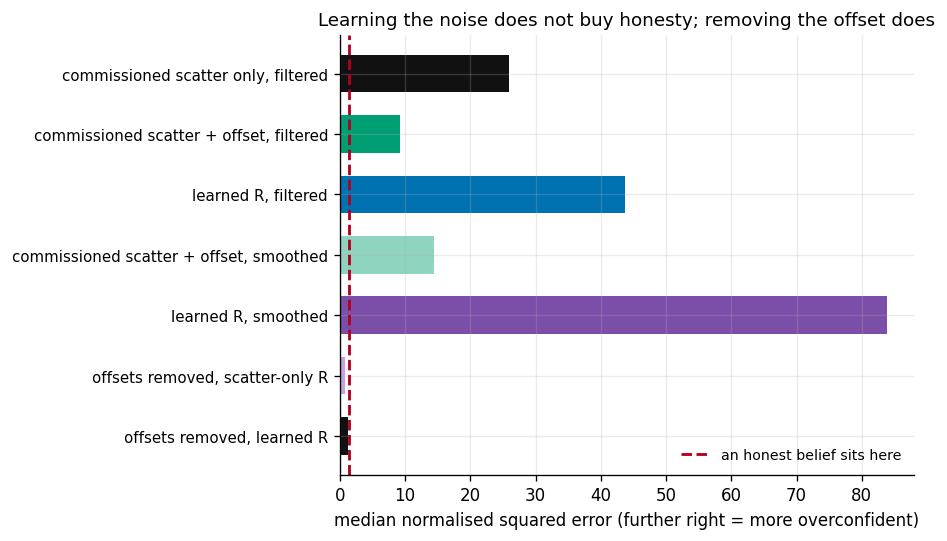

In [13]:
nv.offsets_removed(final)

## What four cameras did and did not buy

They did not buy a better `R`. Every camera's learned noise came out below what
commissioning measured, and the belief got less honest, exactly as with one.

What they did buy is visible in the last table: with each camera's ground-truth sample
mean subtracted, the same machinery is well behaved. That subtraction is an
evaluation-only ceiling, not a deployable estimator. Multiple cameras can identify
**relative** offsets when the route links their observation windows through a shared
trajectory; a common translation of position against all offsets remains invisible.
Notebook 4 derives that statement and tests the augmented-state estimator.

---

*One recorded Gazebo session, one clock, no synthetic data. All estimator functions are
shared through `notebook_model.py` and all figures through `notebook_views.py`. Ground truth
fields are evaluation-only.*